# Attention experiment
## Attention_PatnaikPearson_20260505.ipynb
## Attention meets nu and tail exponents 
## Choose N and d
## Generate data manifold X, N * d, with tail exponent alphaX
## Suppose we have weight matrices WQ, WK, WV, with tail exponents alphaQ, alphaK, alphaV.
## Define Q = X @ WQ, K = X @ WK, V = X @ WV
## Define AttnQKVX = Attention(Q,K,V) = softmax( Q K^T / sqrt(d)) V (row-wise softmax)
## Calculate PP(AttnQKVX), relate this to PP(X), PP(WQ), PP(WK), PP(WV)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd

In [2]:
import PatnaikPearson as pp
import cupy

In [3]:
N = 1000
d = 1000
this_alphaX = 2.0
this_alphaQ = 1.5
this_alphaK = 3.0
this_alphaV = 2.5

#actual_nu_AttnQKV, estimate_nu_AttnQKV, actual_alpha_AttnQKV, estimate_alpha_AttnQKV = 

results_dict = pp.attention_experiment_new(N, d, this_alphaX, this_alphaQ, this_alphaK, this_alphaV, verbose = False)

actual_pp_dim_AttnQKV = results_dict["actual_pp_dim_AttnQKV"] 
estimate_pp_dim_AttnQKV = results_dict["estimate_pp_dim_AttnQKV"] 
actual_alpha_AttnQKV = results_dict["actual_alpha_AttnQKV"] 
estimate_alpha_AttnQKV = results_dict["estimate_alpha_AttnQKV"]

print("actual_pp_dim_AttnQKV = ", actual_pp_dim_AttnQKV)
print("estimate_pp_dim_AttnQKV = ", estimate_pp_dim_AttnQKV)
print("actual_alpha_AttnQKV = ", actual_alpha_AttnQKV)
print("estimate_alpha_AttnQKV = ", estimate_alpha_AttnQKV)

 ** generate_square_weight_matrix: using GPU **
 ** generate_square_weight_matrix: using GPU **
 ** generate_square_weight_matrix: using GPU **
** estimate_product_nu_over_d: use new alpha - check the interpolation thresholds **
** estimate_product_nu_over_d: use new alpha - check the interpolation thresholds **
** estimate_product_nu_over_d: use new alpha - check the interpolation thresholds **
** estimate_product_nu_over_d: use new alpha - check the interpolation thresholds **
 ** calculate_softmax_alpha : need to re-do hardcoded values ** 
** get_alpha_vals_softmax_alpha_vals : need to recalculate for new alpha **
 ** calculate_softmax_alpha : need to re-do hardcoded values ** 
** get_alpha_vals_softmax_alpha_vals : need to recalculate for new alpha **
actual_pp_dim_AttnQKV =  60.61120330868609
estimate_pp_dim_AttnQKV =  29.099167197359993
actual_alpha_AttnQKV =  1.0498685690430811
estimate_alpha_AttnQKV =  0.9042806713260948


# Experiment One :
## this_alphaQ = 1.5

## this_alphaK = 3.0

## this_alphaV = 2.5

## this_alphaX varies between 0.1 and 3.0

In [4]:
N = 1000
d = 1000

these_alphaX = np.arange(0.1,3.1,0.1)
num_values = len(these_alphaX)

#this_alphaX = 2.0
this_alphaQ = 1.5
this_alphaK = 3.0
this_alphaV = 2.5
alphaX_vals = np.zeros(num_values)
actual_pp_dim_AttnQKV_vals = np.zeros(num_values)
estimate_pp_dim_AttnQKV_vals = np.zeros(num_values)
actual_alpha_AttnQKV_vals = np.zeros(num_values)
estimate_alpha_AttnQKV_vals = np.zeros(num_values)

i = 0
for this_alphaX in these_alphaX:
  #actual_nu_AttnQKV, estimate_nu_AttnQKV, actual_alpha_AttnQKV, estimate_alpha_AttnQKV 
  results_dict = pp.attention_experiment_new(N, d, this_alphaX, this_alphaQ, this_alphaK, this_alphaV, verbose = False)

  actual_pp_dim_AttnQKV = results_dict["actual_pp_dim_AttnQKV"]
  estimate_pp_dim_AttnQK = results_dict["estimate_pp_dim_AttnQKV"] 
  actual_alpha_AttnQKV = results_dict["actual_alpha_AttnQKV"] 
  estimate_alpha_AttnQKV = results_dict["estimate_alpha_AttnQKV"]
    
  print("==========================================")
  print(i, "alphaX = ", this_alphaX)
  print(i, "actual_pp_dim_AttnQKV = ", actual_pp_dim_AttnQKV)
  print(i, "estimate_pp_dim_AttnQKV = ", estimate_pp_dim_AttnQKV)
  print(i, "actual_alpha_AttnQKV = ", actual_alpha_AttnQKV)
  print(i, "estimate_alpha_AttnQKV = ", estimate_alpha_AttnQKV)
  alphaX_vals[i] = this_alphaX
  actual_pp_dim_AttnQKV_vals[i] = actual_pp_dim_AttnQKV
  estimate_pp_dim_AttnQKV_vals[i] = estimate_pp_dim_AttnQKV
  actual_alpha_AttnQKV_vals[i] = actual_alpha_AttnQKV
  estimate_alpha_AttnQKV_vals[i] = estimate_alpha_AttnQKV
  i += 1

 ** generate_square_weight_matrix: using GPU **
 ** generate_square_weight_matrix: using GPU **
 ** generate_square_weight_matrix: using GPU **
** estimate_product_nu_over_d: use new alpha - check the interpolation thresholds **
** estimate_product_nu_over_d: use new alpha - check the interpolation thresholds **
** estimate_product_nu_over_d: use new alpha - check the interpolation thresholds **
** estimate_product_nu_over_d: use new alpha - check the interpolation thresholds **
 ** calculate_softmax_alpha : need to re-do hardcoded values ** 
** get_alpha_vals_softmax_alpha_vals : need to recalculate for new alpha **
 ** calculate_softmax_alpha : need to re-do hardcoded values ** 
** get_alpha_vals_softmax_alpha_vals : need to recalculate for new alpha **
0 alphaX =  0.1
0 actual_pp_dim_AttnQKV =  1.0264092438140808
0 estimate_pp_dim_AttnQKV =  29.099167197359993
0 actual_alpha_AttnQKV =  0.2975161565897174
0 estimate_alpha_AttnQKV =  0.36091903530660935
 ** generate_square_weight_matr

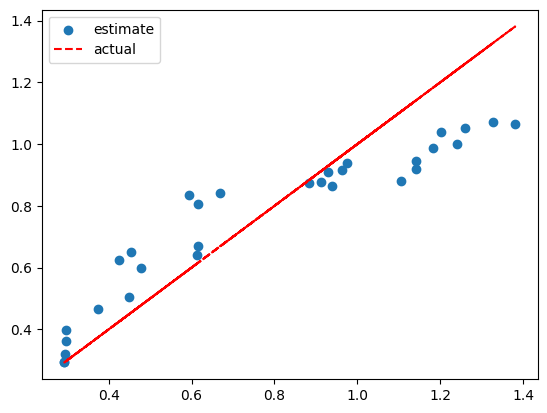

In [7]:
plt.scatter(actual_alpha_AttnQKV_vals, estimate_alpha_AttnQKV_vals, label = "estimate")
plt.plot(actual_alpha_AttnQKV_vals, actual_alpha_AttnQKV_vals, linestyle = "--", color = "red", label = "actual")
plt.legend()
plt.show()

# Generate alphaX, alphaQ, alphaK, alphaV randomly

shape : (10000,)
min : 0.143262054130339
max : 18.58866092208731
sum : 14804.419443943694
mean : 1.4804419443943695
std : 1.3139025688782522
norm : 197.94060501137838


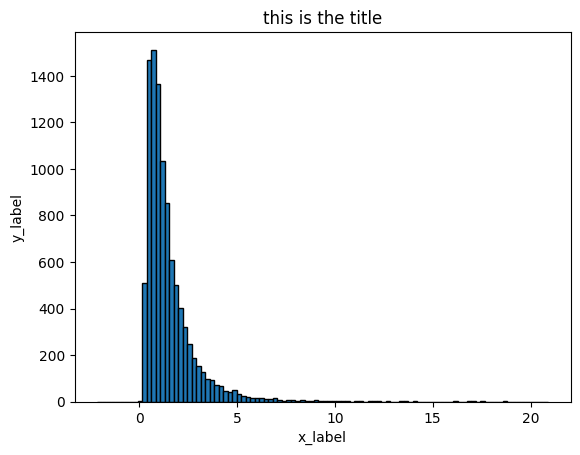

In [15]:
num_iterations = 10000

xx_vals = np.zeros(num_iterations)

for i in range(num_iterations):
    xx = 0.1 + np.exp(0.8 * np.random.normal(0,1))
    xx_vals[i] = xx

pp.display_stats(xx_vals)

pp.plot_histogram(xx_vals)

In [17]:
# Generate 
N = 1000
d = 1000

num_iterations = 100
min_alpha = 0.1
exp_scaling = 0.8

alphaX_vals = np.zeros(num_iterations)
alphaQ_vals = np.zeros(num_iterations)
alphaK_vals = np.zeros(num_iterations)
alphaV_vals = np.zeros(num_iterations)
actual_pp_dim_AttnQKV_vals = np.zeros(num_iterations)
estimate_pp_dim_AttnQKV_vals = np.zeros(num_iterations)
actual_alpha_AttnQKV_vals = np.zeros(num_iterations)
estimate_alpha_AttnQKV_vals = np.zeros(num_iterations)

for i in range(num_iterations):
    this_uniform = np.random.uniform(0,1)
    this_alphaX = min_alpha + this_uniform + np.exp(exp_scaling * np.random.normal(0,1))
    this_alphaQ = min_alpha + this_uniform + np.exp(exp_scaling * np.random.normal(0,1))
    this_alphaK = min_alpha + this_uniform + np.exp(exp_scaling * np.random.normal(0,1))
    this_alphaV = min_alpha + this_uniform + np.exp(exp_scaling * np.random.normal(0,1))

    results_dict = pp.attention_experiment_new(N, d, this_alphaX, this_alphaQ, this_alphaK, this_alphaV, verbose = False)

    actual_pp_dim_AttnQKV = results_dict["actual_pp_dim_AttnQKV"]  
    estimate_pp_dim_AttnQK = results_dict["estimate_pp_dim_AttnQKV"] 
    actual_alpha_AttnQKV = results_dict["actual_alpha_AttnQKV"] 
    estimate_alpha_AttnQKV = results_dict["estimate_alpha_AttnQKV"]
    
    print("==========================================")
    print(i, "alphaX = ", this_alphaX, "alphaQ = ", this_alphaQ, "alphaK = ", this_alphaK, "alphaV = ", this_alphaV)
    print(i, "actual_pp_dim_AttnQKV = ", actual_pp_dim_AttnQKV)
    print(i, "estimate_pp_dim_AttnQKV = ", estimate_pp_dim_AttnQKV)
    print(i, "actual_alpha_AttnQKV = ", actual_alpha_AttnQKV)
    print(i, "estimate_alpha_AttnQKV = ", estimate_alpha_AttnQKV)
    alphaX_vals[i] = this_alphaX
    alphaQ_vals[i] = this_alphaQ
    alphaK_vals[i] = this_alphaK
    alphaV_vals[i] = this_alphaV
    actual_pp_dim_AttnQKV_vals[i] = actual_pp_dim_AttnQKV
    estimate_pp_dim_AttnQKV_vals[i] = estimate_pp_dim_AttnQKV
    actual_alpha_AttnQKV_vals[i] = actual_alpha_AttnQKV
    estimate_alpha_AttnQKV_vals[i] = estimate_alpha_AttnQKV



 ** generate_square_weight_matrix: using GPU **
 ** generate_square_weight_matrix: using GPU **
 ** generate_square_weight_matrix: using GPU **
** estimate_product_nu_over_d: use new alpha - check the interpolation thresholds **
** estimate_product_nu_over_d: use new alpha - check the interpolation thresholds **
** estimate_product_nu_over_d: use new alpha - check the interpolation thresholds **
** estimate_product_nu_over_d: use new alpha - check the interpolation thresholds **
 ** calculate_softmax_alpha : need to re-do hardcoded values ** 
** get_alpha_vals_softmax_alpha_vals : need to recalculate for new alpha **
 ** calculate_softmax_alpha : need to re-do hardcoded values ** 
** get_alpha_vals_softmax_alpha_vals : need to recalculate for new alpha **
0 alphaX =  1.3432955163547342 alphaQ =  1.4209216389310788 alphaK =  1.4589046797292664 alphaV =  1.5966747205861784
0 actual_pp_dim_AttnQKV =  1.7838535892574565
0 estimate_pp_dim_AttnQKV =  29.099167197359993
0 actual_alpha_AttnQKV

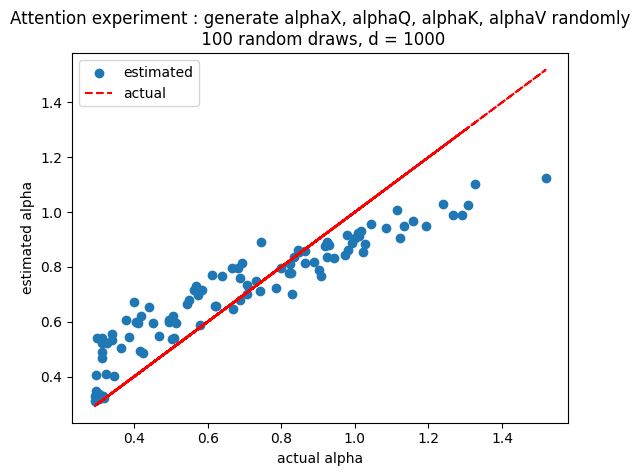

In [25]:
this_title = "Attention experiment : generate alphaX, alphaQ, alphaK, alphaV randomly"
this_title += "\n " + str(num_iterations) + " random draws, d = " + str(d)

plt.scatter(actual_alpha_AttnQKV_vals, estimate_alpha_AttnQKV_vals, label = "estimated")
plt.plot(actual_alpha_AttnQKV_vals, actual_alpha_AttnQKV_vals, linestyle="--", color = "red", label="actual")
plt.xlabel("actual alpha")
plt.ylabel("estimated alpha")
plt.legend()
plt.title(this_title)
#plt.savefig('attention_experiment_one.pdf', dpi=300, bbox_inches='tight')
plt.show()